C:\Users\met48\AppData\Local\Temp\ipykernel_19364\3221643240.py:93: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_outputs = torch.tensor(train_outputs).float()
sampling loop time step: 100%|██████████| 20/20 [00:00<00:00, 21.55it/s]


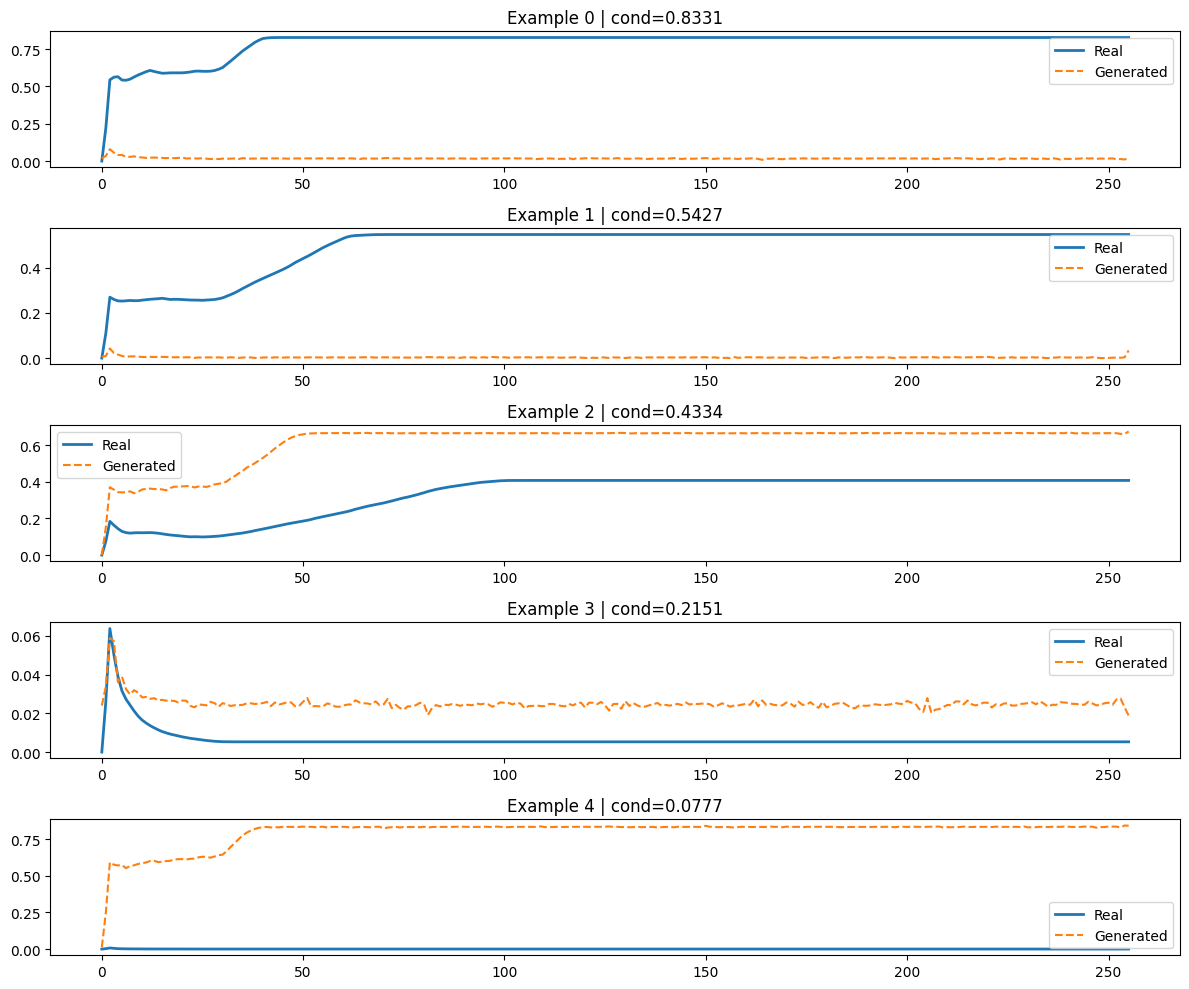

In [8]:
import sys
import torch
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils import data
from tqdm import tqdm as tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

import matplotlib
# matplotlib.use("Agg")

# ---------- IMPORT ----------
sys.path.insert(0, r"C:\Users\met48\Desktop\biodiffusion-main\biodiffusion-main\src\signal")
from modules.modules1D_cond import Unet1D, GaussianDiffusion1D


# ---------- DATASET ----------
class RealSurrogateDataset(data.Dataset):
    def __init__(self, inputs, outputs):
        self.x = inputs.float()
        self.y = outputs.float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        cond = self.x[idx]
        signal = self.y[idx].unsqueeze(0)  # (1, 128)

        return {
            "org_data": signal,
            "cond_data": cond
        }


# ---------- DEVICE ----------
device = "cpu"


# ---------- LOAD DATA ----------

def import_ff_data(filename):
    expected_columns=155
    data = []
    with open(filename, 'r') as file:
        for line in file:
            row = line.strip().split(',')
            if len(row) < expected_columns:
                row += [np.nan] * (expected_columns - len(row))
            data.append(row)
    df = pd.DataFrame(data)
    def fill_last_valid(row):
        for i in range(1, len(row)):
            if pd.isna(row[i]):
                row[i] = row[i - 1]  
        return row
    df_filled = df.apply(fill_last_valid, axis=1)
    return df_filled
    
data_output = import_ff_data("C:/Users/met48/Desktop/TS-Clustering/SimData/forest_fire_outputs_burned.csv")

data_input = pd.read_csv(
    r"C:/Users/met48/Desktop/TS-Clustering/SimData/forest_fire_inputs.csv",
    sep=" ",
    header=None
)

# --- scale outputs ---
scaler = MinMaxScaler()
data_output_scaled = scaler.fit_transform(data_output)
data_output = pd.DataFrame(data_output_scaled)

# --- combine ---
dataf = pd.concat([data_input, data_output], axis=1)

# --- sample ---
dataf = dataf.sample(n=20000, random_state=1)

# --- split ---
train_data_pd, valid_data = train_test_split(dataf, test_size=0.2, random_state=42)

# --- tensors ---
train_inputs = torch.tensor(train_data_pd.iloc[:, :1].values, dtype=torch.float32)
train_outputs = torch.tensor(train_data_pd.iloc[:, 1:].values, dtype=torch.float32)

valid_inputs = torch.tensor(valid_data.iloc[:, :1].values, dtype=torch.float32)
valid_outputs = torch.tensor(valid_data.iloc[:, 1:].values, dtype=torch.float32)

import torch.nn.functional as F

train_outputs = torch.tensor(train_outputs).float()

train_outputs = F.interpolate(
    train_outputs.unsqueeze(1),
    size=256,
    mode="linear",
    align_corners=False
).squeeze(1)

valid_outputs = F.interpolate(
    valid_outputs.unsqueeze(1),
    size=256,
    mode="linear",
    align_corners=False
).squeeze(1)


# ---------- DATASET INSTANCE (FIXED) ----------
dataset = RealSurrogateDataset(train_inputs, train_outputs)

loader = data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)


# ---------- MODEL ----------
model = Unet1D(
    dim=16,
    channels=1,
    self_condition=False
).to(device)

diffusion = GaussianDiffusion1D(
    model,
    seq_length=256,
    timesteps=20,
    objective="pred_v"
).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=1e-4)


# ---------- TRAIN ----------
for epoch in range(10):
    for batch in tqdm(loader, ascii=True, leave=True):
        x = batch["org_data"].to(device)
        cond = batch["cond_data"].to(device).view(-1, 1)

        opt.zero_grad(set_to_none=True)

        loss = diffusion(x, cond)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        opt.step()


# =========================================================
# VALIDATION INFERENCE (REAL vs GENERATED) — 5 EXAMPLES
# =========================================================

model.eval()

# pick 5 validation samples
idx = torch.randperm(len(valid_inputs))[:5]

val_conds = valid_inputs[idx].to(device)
val_reals = valid_outputs[idx].to(device)  # (5, 128)

with torch.no_grad():
    gen = diffusion.sample(
        input_cond=val_conds,
        batch_size=5
    )

gen = gen.cpu()
val_reals = val_reals.cpu()
val_conds = val_conds.cpu()

plt.figure(figsize=(12, 10))

for i in range(5):
    plt.subplot(5, 1, i + 1)

    plt.plot(val_reals[i].squeeze(), label="Real", linewidth=2)
    plt.plot(gen[i, 0], label="Generated", linestyle="--")

    plt.title(f"Example {i} | cond={val_conds[i].item():.4f}")
    plt.legend()

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch

def evaluate_model_diffusion(real_samples, generated_samples):
    """
    real_samples: [N, 128] or [N, 1, 128]
    generated_samples: [N, 1, 128]
    """

    # -------------------------
    # convert to numpy safely
    # -------------------------
    if isinstance(real_samples, torch.Tensor):
        real_samples = real_samples.detach().cpu()

    if isinstance(generated_samples, torch.Tensor):
        generated_samples = generated_samples.detach().cpu()

    # -------------------------
    # fix shape: [N, 128]
    # -------------------------
    if real_samples.ndim == 3:
        real_samples = real_samples.squeeze(1)

    if generated_samples.ndim == 3:
        generated_samples = generated_samples.squeeze(1)

    # -------------------------
    # flatten
    # -------------------------
    y_true = real_samples.numpy().flatten()
    y_pred = generated_samples.numpy().flatten()

    # -------------------------
    # metrics
    # -------------------------
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Validation MSE: {mse:.6f}")
    print(f"Validation MAE: {mae:.6f}")
    print(f"Validation R² Score: {r2:.6f}")

    return mse, mae, r2

In [14]:
with torch.no_grad():
    gen = diffusion.sample(
        input_cond=valid_inputs[:len(valid_inputs)],
        batch_size=8
    )

evaluate_model_diffusion(valid_outputs[:len(gen)], gen)

sampling loop time step: 100%|██████████| 20/20 [00:00<00:00, 22.27it/s]

Validation MSE: 0.234159
Validation MAE: 0.365655
Validation R² Score: -0.859708


(0.23415932059288025, 0.3656550943851471, -0.8597079515457153)